In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences.base import TipVoltageSweep, Sequence, RFPowerSweep
from edes.experiments.devices.base import Instrument
from edes.utils.file_handling import load_latest_data
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
from edes.utils.utils import beep_VS
beep_VS()

In [3]:
exp = Experiment('3layer_trapping_061526')

>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> Connected to KEITHLEY INSTRUMENTS INC.,MODEL 2100,1,01.07-01-01
>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> ERROR initializing device Valon: ('VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.', 'setting Valon_frequency to 1472000000')


In [4]:
exp.list_devices()

['Agilent', 'FEtip_PSU', 'Keithley', 'LNA_PSU', 'SSA']

In [22]:
exp.FEtip_PSU.ramp_down(0)

In [21]:
tip_Vsweep = TipVoltageSweep(saving_dir=exp.saving_dir, 
                             V_start=800, V_stop=2200, V_step=100, R=100e6, 
                             N_avg=8, t_PSU_settle=2, t_meas_delay=0.2, 
                             FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)

In [22]:
file = tip_Vsweep.run_save()

100%|███████████████████████████████████████████| 14/14 [01:41<00:00,  7.25s/it]


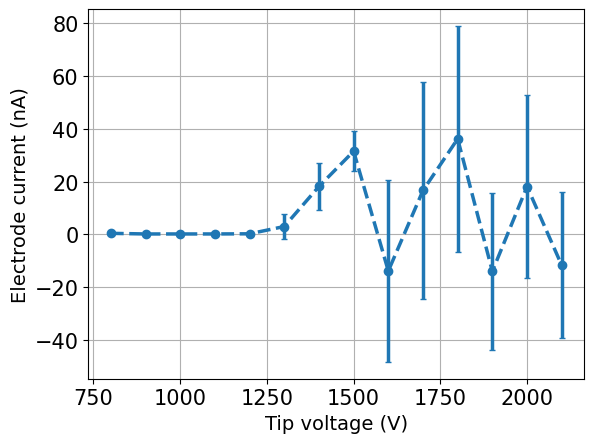

In [23]:
plot_errbar(file['all_V'], np.mean(file['all_I'], axis=1)*1e9, yerr=np.std(file['all_I'], axis=1)*1e9, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (nA)')
# plt.yscale('log')

In [10]:
tip_Vsweep = TipVoltageSweep(name='bl3_current_withtip_others_floating',saving_dir=exp.saving_dir, 
                             V_start=1000, V_stop=2500, V_step=100, R=100e6, 
                             N_avg=10, t_PSU_settle=5, t_meas_delay=1, 
                             FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Keithley)

In [11]:
file = tip_Vsweep.run_save()

100%|██████████| 15/15 [03:50<00:00, 15.39s/it]


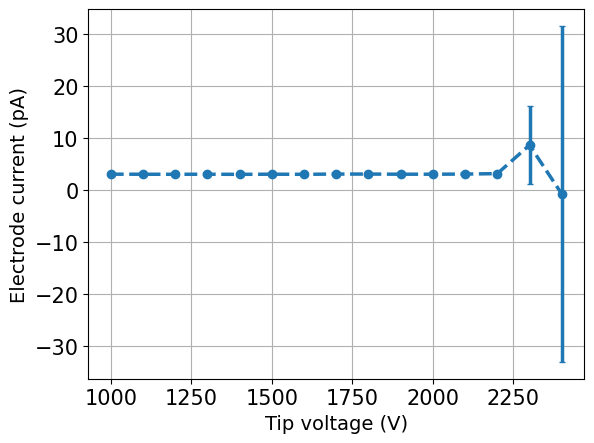

In [12]:
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (pA)')
# plt.yscale('log')

In [24]:
exp.close_all()

>>> ERROR closing device: 'Keithley2100' object has no attribute 'instrument'


In [16]:
exp.FEtip_PSU.ramp_down(0)

In [4]:
class RFPowerSweepVolLinear(Sequence): 
    def __init__(self, name='RFPowerSweep', saving_dir=None,
                 t_valon_settle=8, t_meas_delay=8, t_power_switch=0.1, 
                 t_data_buffer=1,
                 P_min_dBm = 1, P_max_dBm = 10, R=50, steps=800, N_avg=5, 
                 V_on=1400, V_off=700,
                 SSA_freq_center = None, SSA_freq_span = None,
                 SSA_RBW = 30, SSA_SWT=1,
                 Valon: 'Valon | None' =None, SSA: 'SSA3032X_R | None'=None, FEtip_PSU: 'PS350_viaDP832A | None'=None,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, **kwargs)
        self.t_valon_settle = t_valon_settle
        self.t_meas_delay = t_meas_delay
        self.t_power_switch = t_power_switch
        self.t_data_buffer = t_data_buffer
        self.P_min_dBm = P_min_dBm
        self.P_max_dBm = P_max_dBm
        self.V_min = dBm_to_Vp(self.P_min_dBm)
        self.V_max = dBm_to_Vp(self.P_max_dBm)
        self.R = R
        self.steps = steps
        self.N_avg = N_avg
        self.V_on = V_on
        self.V_off = V_off
        self.SSA_freq_center = SSA_freq_center
        self.SSA_freq_span = SSA_freq_span
        self.SSA_RBW = SSA_RBW 
        self.SSA_SWT = SSA_SWT
        self.Valon = Valon
        self.SSA = SSA
        self.FEtip_PSU = FEtip_PSU
        self.parameters = {
            't_valon_settle': t_valon_settle,
            't_meas_delay': t_meas_delay,
            't_data_buffer': t_data_buffer,
            't_power_switch': t_power_switch,
            'P_min_dBm': P_min_dBm,
            'P_max_dBm': P_max_dBm,
            'R': R,
            'steps': steps,
            'N_avg': N_avg, 
            'V_on': V_on,
            'V_off': V_off,
            'SSA_freq_center': SSA_freq_center, 
            'SSA_freq_span': SSA_freq_span,
            'Valon': Valon.name if Valon is not None else None,
            'SSA': SSA.name if SSA is not None else None,   
            'FEtip_PSU': FEtip_PSU.name if FEtip_PSU is not None else None
        }
        self.SSA_init(SSA_freq_center, SSA_freq_span, SSA_RBW, SSA_SWT)
        
    # def test(self):
    #     print((self.V_min,self.V_max))

    def SSA_init(self, freq_center, span, RBW, SWT):
        self.SSA.set_freq_center(freq_center)
        self.SSA.set_freq_span(span)
        self.SSA.set_RBW(RBW)
        self.SSA.set_SWT(SWT)

    def run(self):
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        voltage_scan = np.linspace(self.V_min, self.V_max, self.steps)
        dBm_scan = Vp_to_dBm(voltage_scan,R=self.R)
        self.FEtip_PSU.set_voltage(self.V_on)
        all_meas = []
        all_t_start = [] 
        all_t_end = []
        self.Valon.set_power(dBm_scan[0])
        self.Valon.output_on()
        for _ in trange(self.N_avg):
            self.Valon.set_power(dBm_scan[0])
            time.sleep(self.t_valon_settle)
            self.SSA.clear_averaging()
            self.SSA.get_trace()
            t0 = time.time()
            for P_dbm in dBm_scan:
                self.Valon.set_power(P_dbm)
                time.sleep(self.t_power_switch)
            t1 = time.time()
            self.Valon.set_power(dBm_scan[0])
            time.sleep(self.t_meas_delay)
            data = self.SSA.get_trace()
            all_meas.append(data)
            all_t_start.append(t0)
            all_t_end.append(t1)
        self.FEtip_PSU.ramp_down(0)
        self.Valon.set_power(0)
        self.Valon.output_off()

        return {'dBm_scan': dBm_scan, 'all_meas': np.array(all_meas), 't_start': np.array(all_t_start), 't_end': np.array(all_t_end)}
    

In [18]:
class RFPowerSweepVolLinearAccurate(Sequence): 
    def __init__(self, name='RFPowerSweep', saving_dir=None,
                 t_valon_settle=8, t_meas_delay=8, t_power_switch=0.1, 
                 t_data_buffer=1,
                 P_min_dBm = 1, P_max_dBm = 10, R=50, steps=800, N_avg=5, 
                 V_on=1400, V_off=700,
                 SSA_freq_center = None, SSA_freq_span = None,
                 SSA_RBW = 30, SSA_SWT=1,
                 Valon: 'Valon | None' =None, SSA: 'SSA3032X_R | None'=None, FEtip_PSU: 'PS350_viaDP832A | None'=None,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, **kwargs)
        self.t_valon_settle = t_valon_settle
        self.t_meas_delay = t_meas_delay
        self.t_power_switch = t_power_switch
        self.t_data_buffer = t_data_buffer
        self.P_min_dBm = P_min_dBm
        self.P_max_dBm = P_max_dBm
        self.V_min = dBm_to_Vp(self.P_min_dBm)
        self.V_max = dBm_to_Vp(self.P_max_dBm)
        self.R = R
        self.steps = steps
        self.N_avg = N_avg
        self.V_on = V_on
        self.V_off = V_off
        self.SSA_freq_center = SSA_freq_center
        self.SSA_freq_span = SSA_freq_span
        self.SSA_RBW = SSA_RBW 
        self.SSA_SWT = SSA_SWT
        self.Valon = Valon
        self.SSA = SSA
        self.FEtip_PSU = FEtip_PSU
        self.parameters = {
            't_valon_settle': t_valon_settle,
            't_meas_delay': t_meas_delay,
            't_data_buffer': t_data_buffer,
            't_power_switch': t_power_switch,
            'P_min_dBm': P_min_dBm,
            'P_max_dBm': P_max_dBm,
            'R': R,
            'steps': steps,
            'N_avg': N_avg, 
            'V_on': V_on,
            'V_off': V_off,
            'SSA_freq_center': SSA_freq_center, 
            'SSA_freq_span': SSA_freq_span,
            'Valon': Valon.name if Valon is not None else None,
            'SSA': SSA.name if SSA is not None else None,   
            'FEtip_PSU': FEtip_PSU.name if FEtip_PSU is not None else None
        }
        self.SSA_init(SSA_freq_center, SSA_freq_span, SSA_RBW, SSA_SWT, N_avg)

    def SSA_init(self, freq_center, span, RBW, SWT, N_AVG):
        self.SSA.set_freq_center(freq_center)
        self.SSA.set_freq_span(span)
        self.SSA.set_RBW(RBW)
        self.SSA.set_SWT(SWT)
        self.SSA.set_N_avg(N_AVG)


    def run(self):
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT, self.N_avg)
        voltage_scan = np.linspace(self.V_min, self.V_max, self.steps)
        dBm_scan = Vp_to_dBm(voltage_scan,R=self.R)
        self.FEtip_PSU.set_voltage(self.V_on)
        all_meas = []
        self.Valon.set_power(dBm_scan[0])
        self.Valon.output_on()
        time.sleep(self.t_valon_settle)
        for P_dbm in tqdm(dBm_scan):
            self.Valon.set_power(P_dbm)
            time.sleep(self.t_power_switch)
            data=self.SSA.get_full_trace()
            all_meas.append(data)
        self.FEtip_PSU.ramp_down(0)
        self.Valon.set_power(0)
        self.Valon.output_off()

        return {'dBm_scan': dBm_scan, 'all_meas': np.array(all_meas)}
    

In [14]:
ScanningParameters = {
    'saving_dir': exp.saving_dir,
    't_valon_settle': 8,
    't_meas_delay': 8,
    't_power_switch': 0,
    'P_min_dBm': 3,
    'P_max_dBm': 8,
    'steps': 800,
    'N_avg': 24, 
    'V_on': 2000,
    'V_off': 600,
    'SSA_freq_center': 197.9, 
    'SSA_freq_span': 0, 
    'SSA_RBW': 30, 
    'SSA_SWT': 30,
    'Valon': exp.Valon,
    'SSA': exp.SSA,  
    'FEtip_PSU': exp.FEtip_PSU
}

power_sweep = RFPowerSweepVolLinear(**ScanningParameters)

In [27]:
file = power_sweep.run_save()

  8%|▊         | 2/24 [01:13<13:26, 36.66s/it]/home/electron/Qcodes_contrib_drivers/src/qcodes_contrib_drivers/drivers/Valon/Valon_5015.py:104: UserWarning: read string doesn't end with termination characters
  return [self.visa_handle.read() for _ in range(ltr)]
100%|██████████| 24/24 [14:39<00:00, 36.66s/it]


In [29]:
beep()

In [19]:
ScanningParametersAccurate = {
    'saving_dir': exp.saving_dir,
    't_valon_settle': 8,
    't_meas_delay': 8,
    't_power_switch': 0.1,
    'P_min_dBm': 3,
    'P_max_dBm': 8,
    'steps': 800,
    'N_avg': 24, 
    'V_on': 2000,
    'V_off': 600,
    'SSA_freq_center': 197.9, 
    'SSA_freq_span': 0, 
    'SSA_RBW': 30, 
    'SSA_SWT': 0.2,
    'Valon': exp.Valon,
    'SSA': exp.SSA,  
    'FEtip_PSU': exp.FEtip_PSU
}

power_sweep_accurate = RFPowerSweepVolLinearAccurate(**ScanningParametersAccurate)

In [20]:
file = power_sweep_accurate.run_save()

 42%|████▏     | 335/800 [02:07<02:57,  2.63it/s]/home/electron/Qcodes_contrib_drivers/src/qcodes_contrib_drivers/drivers/Valon/Valon_5015.py:104: UserWarning: read string doesn't end with termination characters
  return [self.visa_handle.read() for _ in range(ltr)]
100%|██████████| 800/800 [05:03<00:00,  2.64it/s]


/tmp/ipykernel_591926/3605552161.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


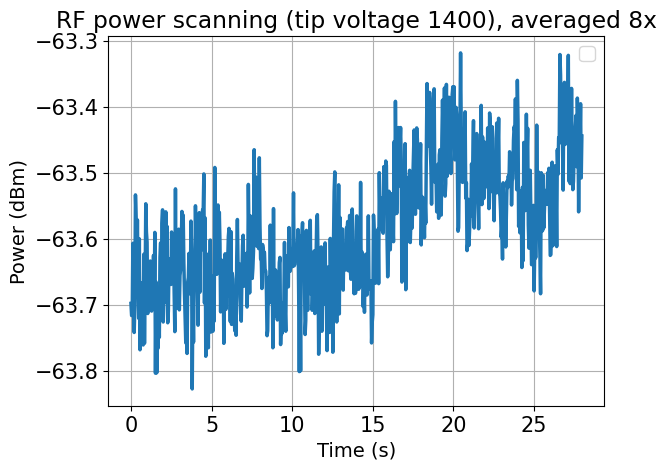

In [13]:
file = load_latest_data()
all_data = file['all_meas'] 
num_points = len(all_data[0])
t_axis = np.linspace(0, 30, num_points) 
idx = np.where(t_axis < 30-2)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f"RF power scanning (tip voltage {ScanningParameters['V_on']}), averaged {ScanningParameters['N_avg']}x")
# plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
# plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()


In [5]:
SSA = exp.SSA
freq_center = 197.9 # MHz
freq_span = 0 # MHz
RBW_AUTO = 0 #1-ON, 0-OFF
VBW_AUTO = 1 #1-ON, 0-OFF
SWT_AUTO = 1 #1-ON, 0-OFF
VBW_RBW_RAT = 1 
RBW = 30 #kHz
VBW = 30 #kHz
SWT = 10000 #ms
N_AVG = 1

# Configure frequency
SSA.write("SENS:FREQ:CENT " + str(freq_center) + " MHz")
SSA.write("SENS:FREQ:SPAN " + str(freq_span) + " MHz")

# Configure bandwidths and sweep time
SSA.write("SENS:BWID:AUTO " + str(RBW_AUTO))
SSA.write("SENS:BWID:VID:AUTO " + str(VBW_AUTO))
SSA.write("SENS:SWE:TIME:AUTO " + str(SWT_AUTO))
SSA.write("SENS:BWID:VID " + str(VBW) + " kHz")
SSA.write("SENS:BWID " + str(RBW) + " kHz")
SSA.write("SENS:BWID:VID:RAT " + str(VBW_RBW_RAT))
SSA.write("SENS:SWE:TIME " + str(SWT) + " ms")
SSA.write(f':AVERage:TRACe1:COUNt {N_AVG}')
SSA.write(':AVERage:TRACe1:STATe ON')

# Set sweep mode to FFT
SSA.write(":SWEep:MODE FFT")

In [6]:
T_idle = 1
T_load = 2 
T_wait = 30 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 3000
V_off = 1000

N_rep = 16 

exp.FEtip_PSU.set_voltage(V_off)
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
exp.SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
# valon.power(11)

dBm_min = 6
dBm_max = 11

# 2. Voltage boundaries matching 6 dBm and 13 dBm
v_min = dBm_to_Vp(dBm_min)
v_max = dBm_to_Vp(dBm_max)

# 3. Create a linear scan of voltage (equal distances)
# 1800 steps matches the resolution of your original array
voltage_scan = np.linspace(v_min, v_max, 800)

dbm_scan = np.around(Vp_to_dBm(voltage_scan), 5)

# all_P = np.arange(6,15,0.005)
all_P = dbm_scan

exp.FEtip_PSU.set_voltage(V_on)
# /valon.buffer_amplifiers_enabled(bool(1))
exp.Valon.set_frequency(1472000000)
exp.Valon.set_power(all_P[0])
exp.Valon.output_on()
for i in tqdm(range(N_rep)):
    exp.Valon.set_power(all_P[0])
    exp.Valon.output_on()
    time.sleep(2)
    exp.SSA.write(":AVERage:TRAC1:CLEar")
    exp.SSA.query(":TRACe1:DATA?")
    t0 = time.time()
    for p in all_P: 
        exp.Valon.set_power(p)
    t1 = time.time()
    time.sleep(2)
    data_str_C = exp.SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)
exp.Valon.set_power(10)
exp.FEtip_PSU.set_voltage(V_off)

100%|███████████████████████████████████████████| 16/16 [05:14<00:00, 19.68s/it]


In [11]:
exp.Valon.output_off()

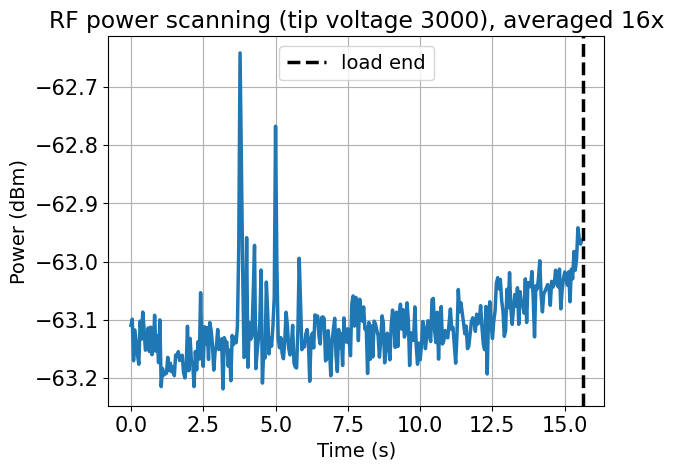

In [7]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < t1-t0)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF power scanning (tip voltage {V_on}), averaged {N_rep}x')
# plt.axvline(t0, linestyle='--', color='r', label='load start') 
plt.axvline(t1-t0, linestyle='--', color='k', label='load end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()


In [10]:
np.savez(f'{exp.saving_dir}/PowerScan_120000.npz', all_data=all_data, t_axis=t_axis)

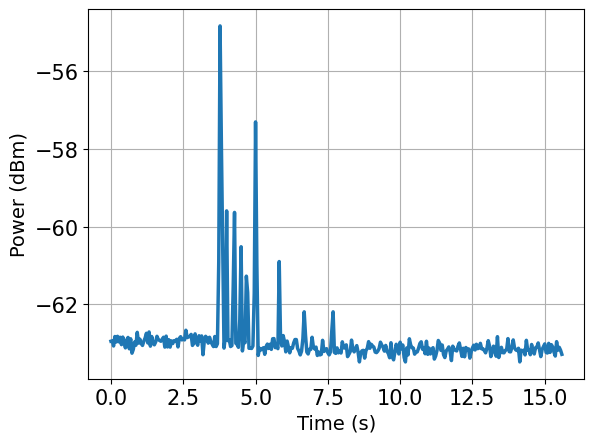

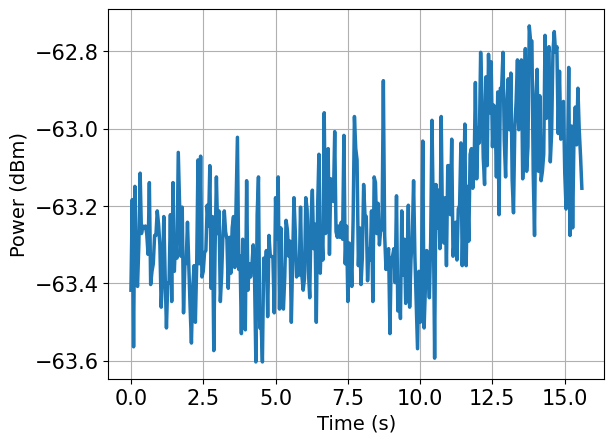

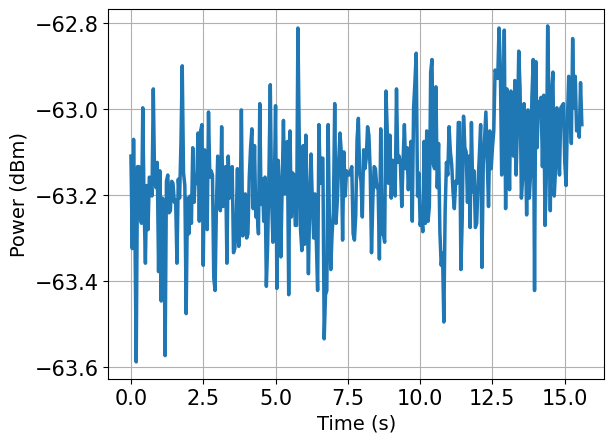

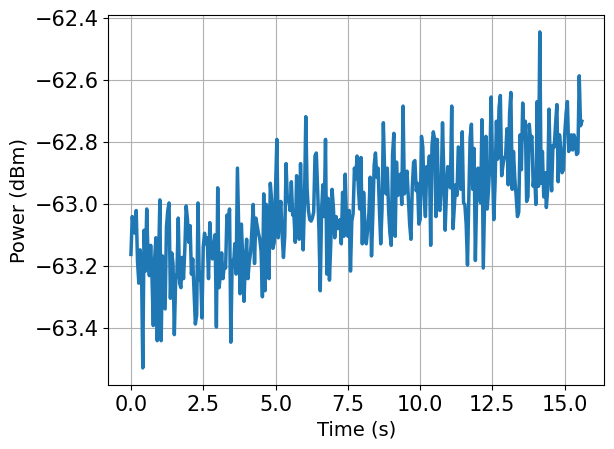

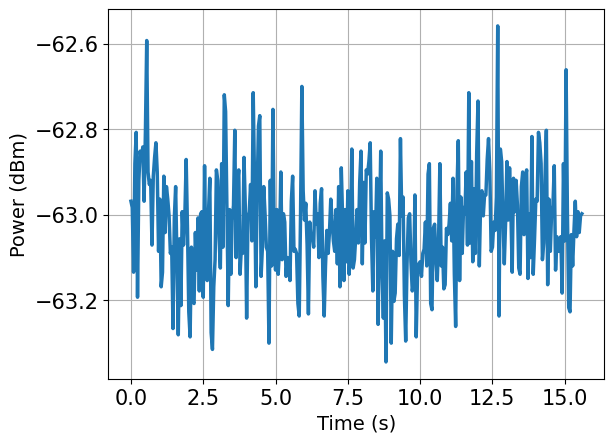

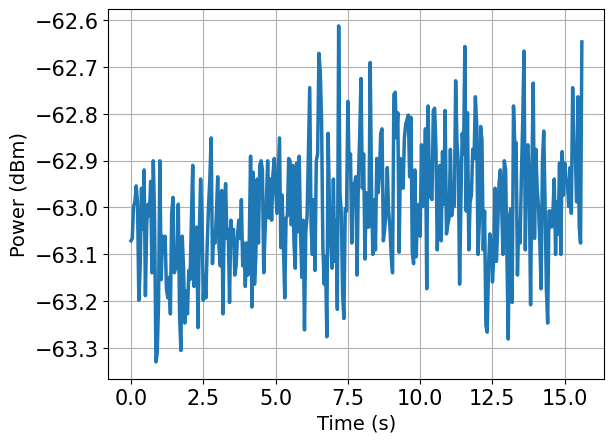

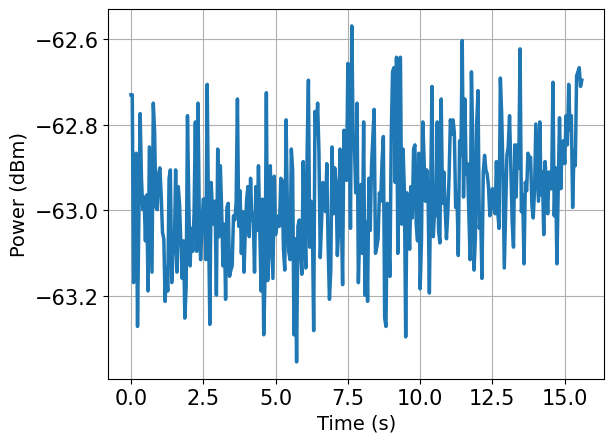

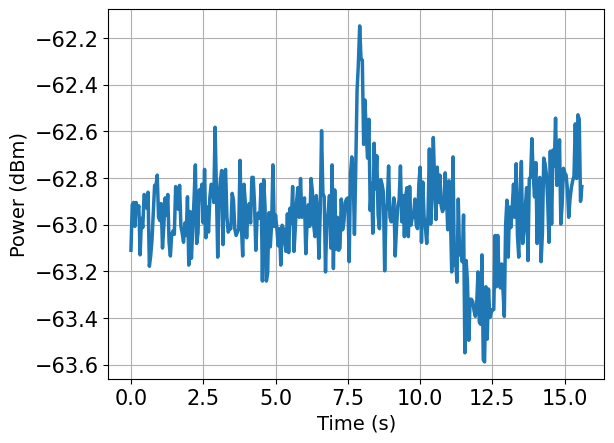

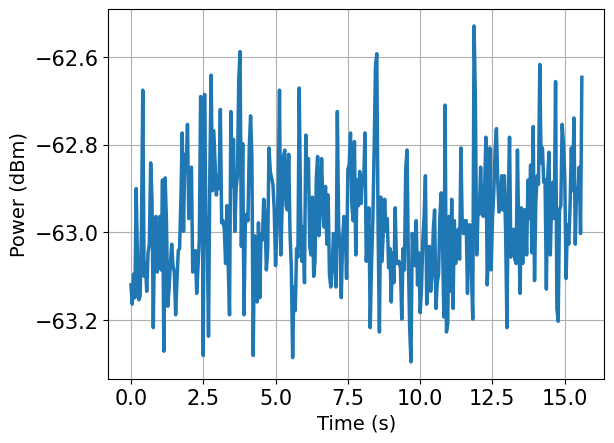

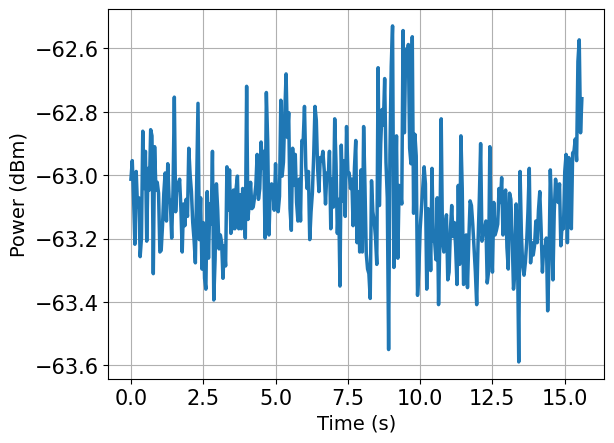

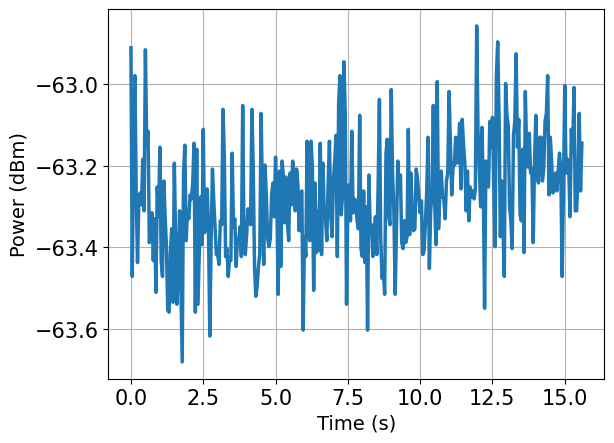

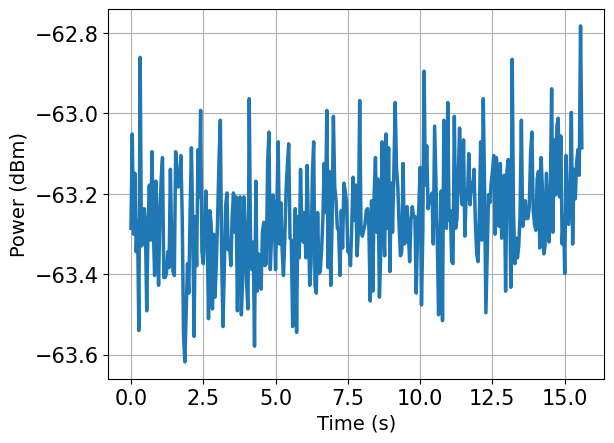

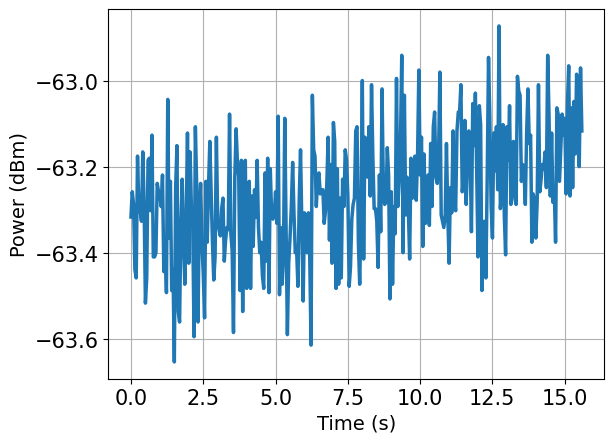

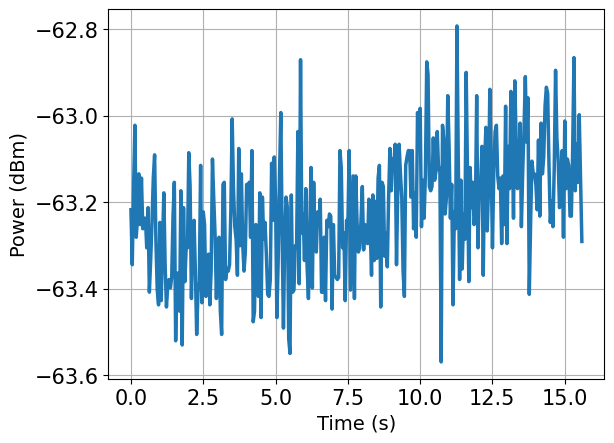

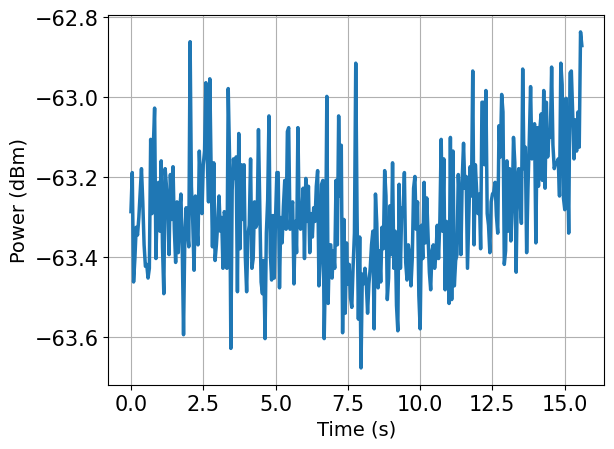

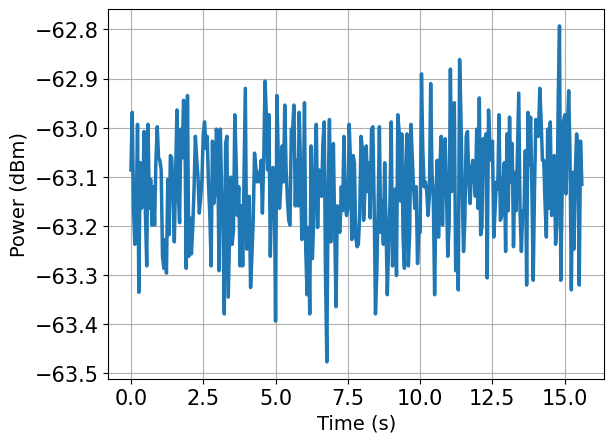

In [9]:
for data in all_data: 
    plot(t_axis[idx], data[idx], xlabel='Time (s)', ylabel='Power (dBm)')
    plt.show()

In [31]:
exp.FEtip_PSU.ramp_down(0)

In [32]:
exp.Valon.output_off()